In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

PATCH_DIR = Path("dataset/train")
VAL_DIR = Path("dataset/validation")

In [3]:
def check_patch(path):
    data = np.load(path)
    image = data["image"]  # (1, D, H, W)
    label = data["label"]  # (1, D, H, W)

    print(f"\n{path.name}")
    print(f"  image shape : {image.shape}")
    print(f"  label shape : {label.shape}")
    print(
        f"  image min/max/mean : {image.min():.3f} / {image.max():.3f} / {image.mean():.3f}"
    )
    print(f"  label unique values: {np.unique(label)}")
    print(f"  foreground voxels  : {(label > 0).sum()} / {label.size}")

    return image, label

In [4]:
def visualise_volume_slices(image, label, title="Volume", num_slices=6):
    """Show multiple slices across the depth axis"""
    img = image[0]
    lbl = label[0]

    D = img.shape[0]
    slice_indices = np.linspace(0, D - 1, num_slices, dtype=int)

    fig, axes = plt.subplots(2, num_slices, figsize=(18, 6))
    fig.suptitle(title)

    for i, s in enumerate(slice_indices):
        axes[0, i].imshow(img[s], cmap="gray")
        axes[0, i].set_title(f"slice {s}")
        axes[0, i].axis("off")

        axes[1, i].imshow(img[s], cmap="gray")
        axes[1, i].imshow(lbl[s], cmap="hot", alpha=0.4)
        axes[1, i].set_title(f"label {s}")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

In [5]:
def visualise_patch(image, label, title="Patch"):
    """Show centre slice of a patch with label overlay"""
    # image/label shape is (1, D, H, W) — squeeze channel dim
    img = image[0]
    lbl = label[0]

    d = img.shape[0] // 2  # centre slice along depth axis

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(title)

    # Image only
    axes[0].imshow(img[d], cmap="gray")
    axes[0].set_title(f"Image (slice {d})")

    # Label only
    axes[1].imshow(lbl[d], cmap="hot")
    axes[1].set_title("Label")

    # Overlay
    axes[2].imshow(img[d], cmap="gray")
    axes[2].imshow(lbl[d], cmap="hot", alpha=0.4)
    axes[2].set_title("Overlay")

    plt.tight_layout()
    plt.show()

In [6]:
def check_volume(path):
    data = np.load(path)
    image = data["image"]
    label = data["label"]

    print(f"\n{path.name}")
    print(f"  image shape : {image.shape}")
    print(f"  label shape : {label.shape}")
    print(
        f"  image min/max/mean : {image.min():.3f} / {image.max():.3f} / {image.mean():.3f}"
    )
    print(f"  label unique values: {np.unique(label)}")
    print(
        f"  foreground voxels  : {(label > 0).sum()} / {label.size} "
        f"({100 * (label > 0).mean():.2f}%)"
    )

    return image, label

Total training patches: 1088

patient_163_patch_03.npz
  image shape : (1, 96, 96, 96)
  label shape : (1, 96, 96, 96)
  image min/max/mean : 0.052 / 1.000 / 0.449
  label unique values: [  0 151 152 153 154]
  foreground voxels  : 98831 / 884736


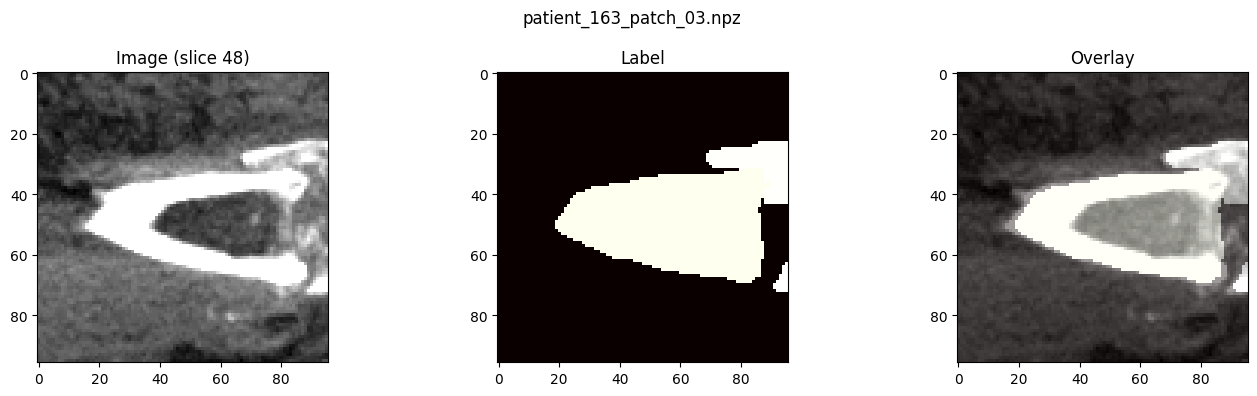


patient_232_patch_00.npz
  image shape : (1, 96, 96, 96)
  label shape : (1, 96, 96, 96)
  image min/max/mean : 0.000 / 1.000 / 0.245
  label unique values: [0]
  foreground voxels  : 0 / 884736


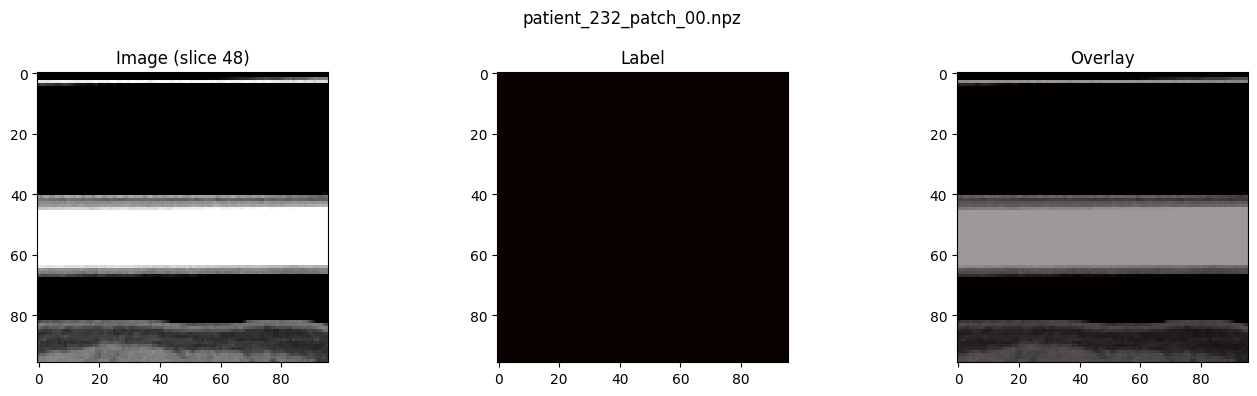


patient_153_patch_02.npz
  image shape : (1, 96, 96, 96)
  label shape : (1, 96, 96, 96)
  image min/max/mean : 0.000 / 1.000 / 0.475
  label unique values: [  0 151 152]
  foreground voxels  : 213056 / 884736


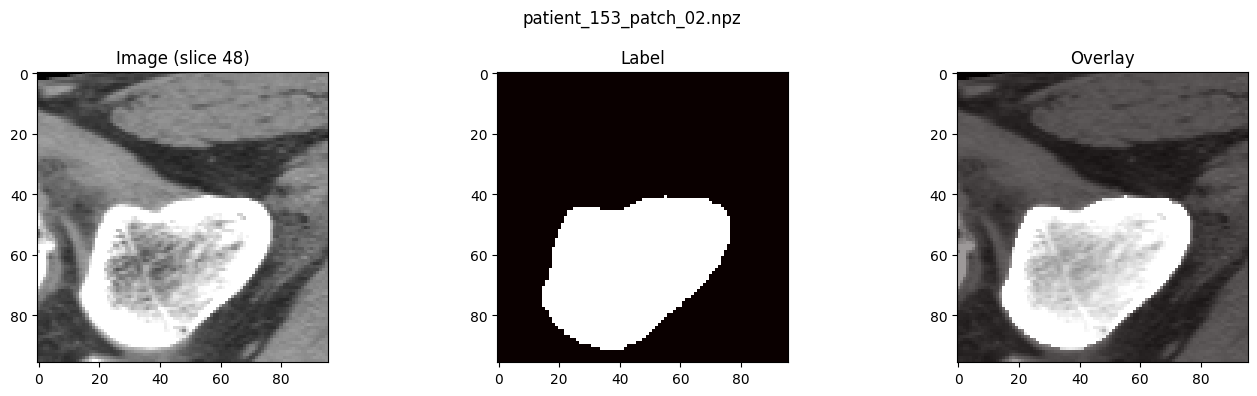


patient_114_patch_00.npz
  image shape : (1, 96, 96, 96)
  label shape : (1, 96, 96, 96)
  image min/max/mean : 0.000 / 1.000 / 0.541
  label unique values: [  0   1 101 102 103]
  foreground voxels  : 163300 / 884736


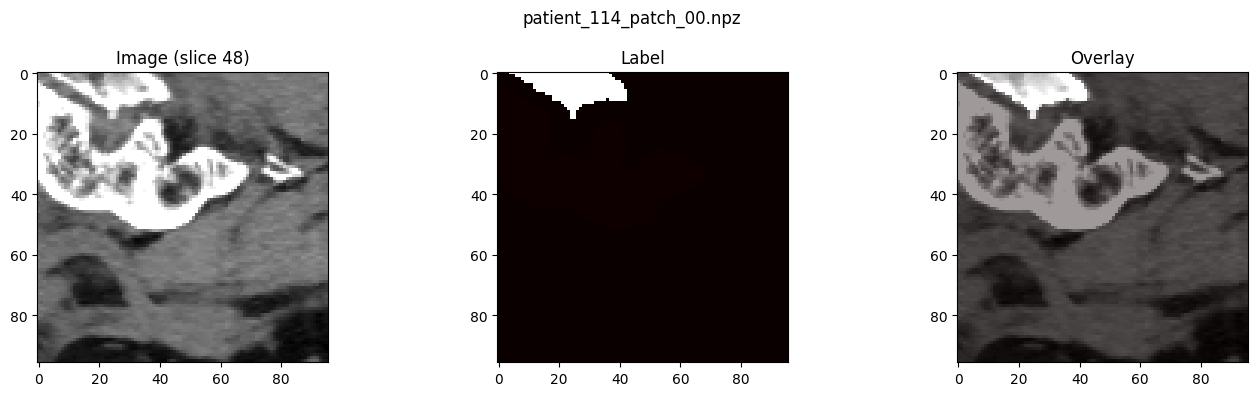


patient_094_patch_01.npz
  image shape : (1, 96, 96, 96)
  label shape : (1, 96, 96, 96)
  image min/max/mean : 0.000 / 1.000 / 0.278
  label unique values: [ 0 51]
  foreground voxels  : 71938 / 884736


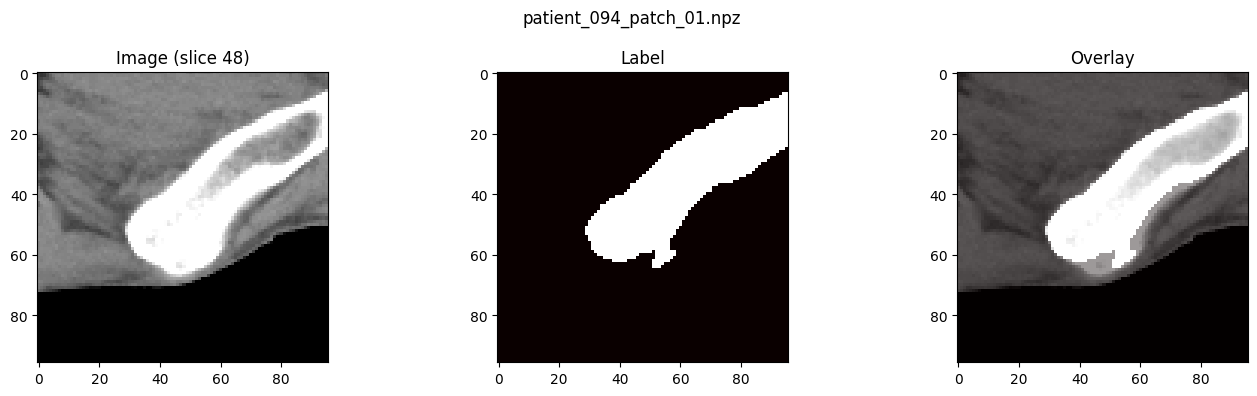

In [13]:
# 1. Check a few random patches
patch_files = sorted((PATCH_DIR / "data").glob("*.npz"))
print(f"Total training patches: {len(patch_files)}")

for path in random.sample(patch_files, min(5, len(patch_files))):
    image, label = check_patch(path)
    visualise_patch(image, label, title=path.name)


Total validation volumes: 34

patient_288.npz
  image shape : (1, 337, 213, 263)
  label shape : (1, 337, 213, 263)
  image min/max/mean : 0.000 / 1.000 / 0.307
  label unique values: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  51  52  53
  54 101 102 103 104 105]
  foreground voxels  : 670666 / 18878403 (3.55%)


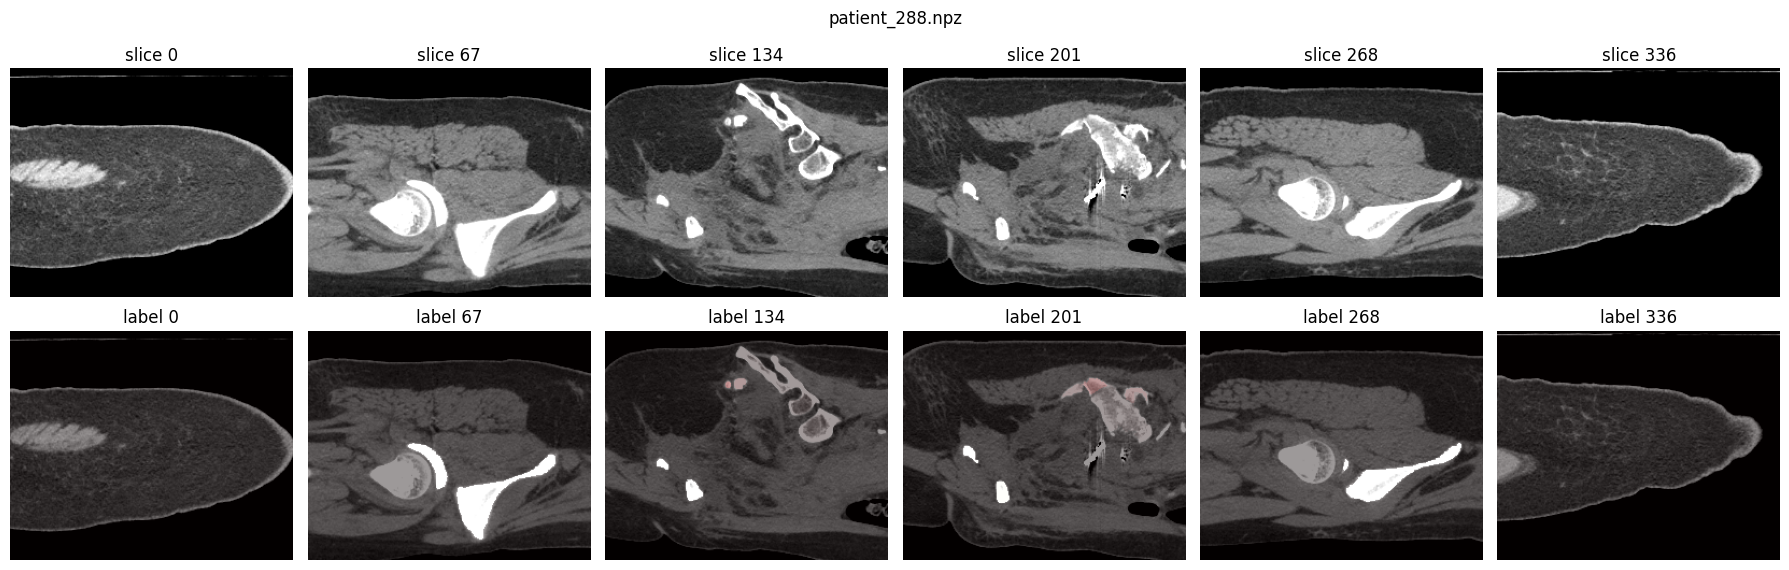


patient_302.npz
  image shape : (1, 157, 300, 278)
  label shape : (1, 157, 300, 278)
  image min/max/mean : 0.000 / 1.000 / 0.278
  label unique values: [  0 151 152 153 154 155 156]
  foreground voxels  : 234073 / 13093800 (1.79%)


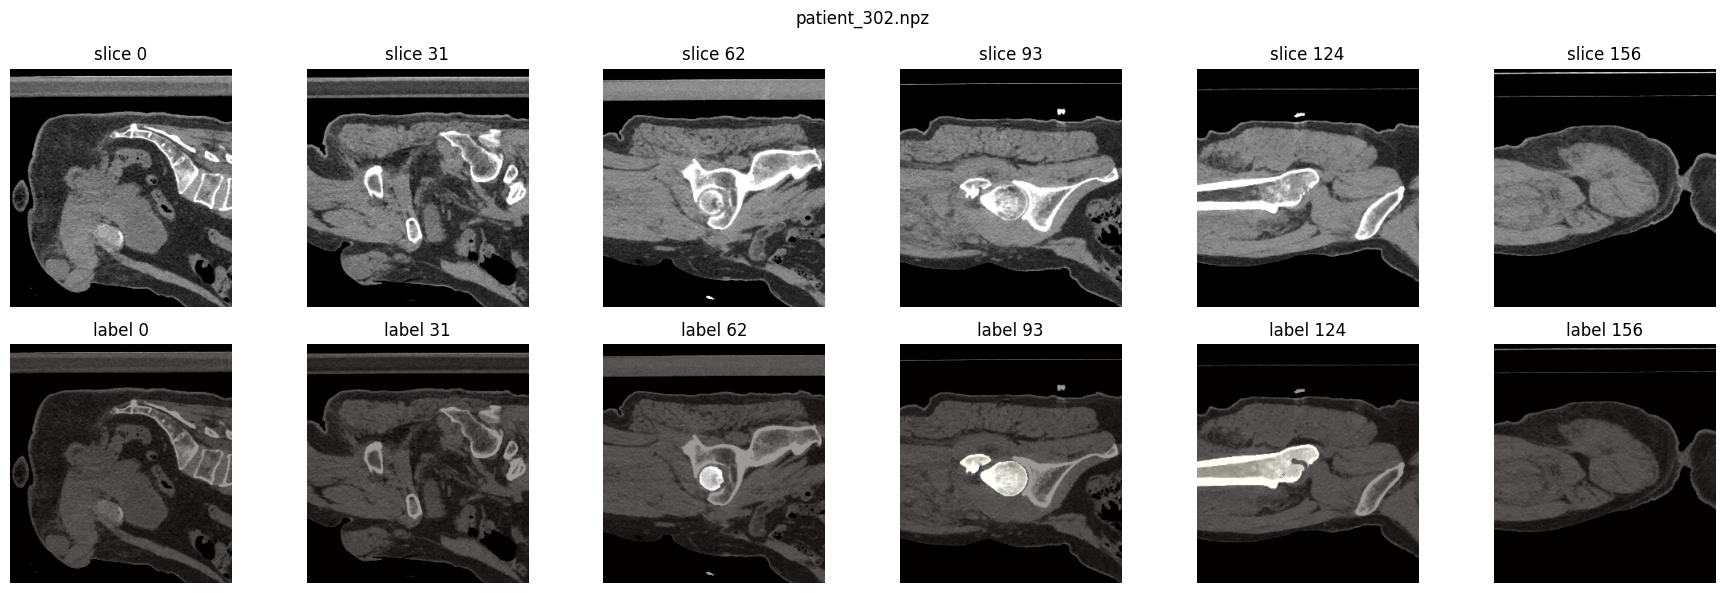


patient_273.npz
  image shape : (1, 371, 226, 250)
  label shape : (1, 371, 226, 250)
  image min/max/mean : 0.000 / 1.000 / 0.302
  label unique values: [  0   1   2   3   4   5   6   7   8   9  51  52  53  54  55  56  57  58
  59  60  61  62 101]
  foreground voxels  : 885495 / 20961500 (4.22%)


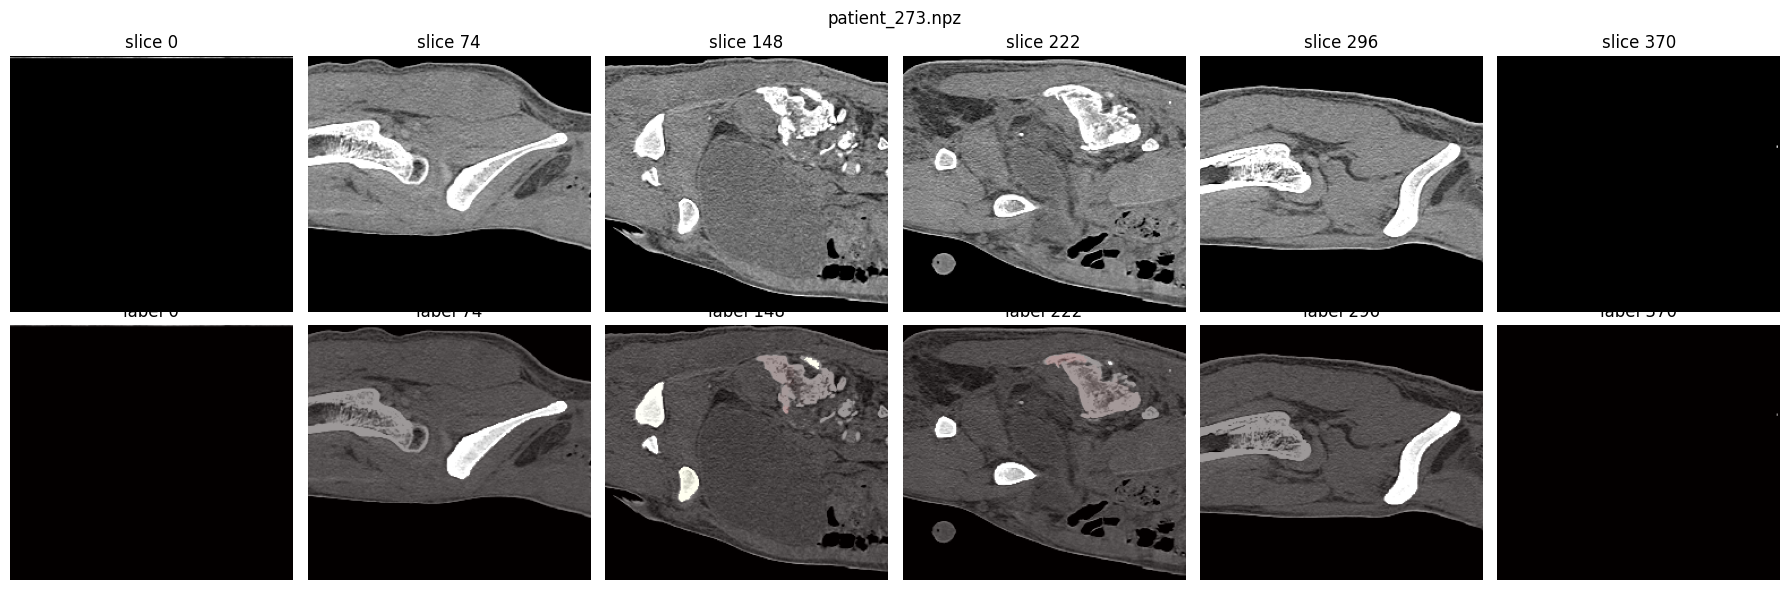

In [14]:
# 2. Check a few validation volumes
val_files = sorted((VAL_DIR / "data").glob("*.npz"))
print(f"\nTotal validation volumes: {len(val_files)}")

for path in random.sample(val_files, min(3, len(val_files))):
    image, label = check_volume(path)
    visualise_volume_slices(image, label, title=path.name)